Notebook for checking number density calculation

First check: dispersion between SV3 rosettes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
import fitsio
import scipy.spatial.transform as trans
from desimodel.footprint import is_point_in_desi
import astropy.io.ascii
from scipy.spatial import cKDTree
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
from CountsinCylinders import *

In [ ]:
#set up auto-reload for development purposes

%load_ext autoreload
%autoreload 2

In [2]:
def angularCut(table,ramin,ramax,decmin,decmax):
    return (table['DEC'] > decmin) & (table['DEC'] < decmax) & \
            (table['RA'] > ramin) & (table['RA'] < ramax)

def raDecToUnitSphere(a, d):
    a = a*np.pi/180
    d = d*np.pi/180
    x = np.cos(a)*np.cos(d)
    y = np.sin(a)*np.cos(d)
    z = np.sin(d)
    return [np.array([x[i],y[i],z[i],1]) for i in range(len(a))]

def MCintegrateholes(randtable,holetable,mask,maskargs,R_hole):
    rands = randtable[mask(randtable,*maskargs)]
    rands['UScoord'] = raDecToUnitSphere(rands['RA'],rands['DEC'])
    randUSmap = [coord[:3] for coord in rands['UScoord']]
    randtree_US = cKDTree(randUSmap)

    
    holemap = [[holetable['x'][i],holetable['y'][i],holetable['z'][i]] for i in range(len(holetable))]
    holetree = cKDTree(holemap)

    holeneighbors = randtree_US.query_ball_tree(holetree,R_hole)
    holemask = [len(n) < 1 for n in holeneighbors]
    randcleaned = rands[holemask]

    return len(randcleaned)/len(rands)

In [3]:
def MCintegrateholes(randtable,holetable,mask,maskargs,R_hole):
    rands = randtable[mask(randtable,*maskargs)]
    rands['UScoord'] = raDecToUnitSphere(rands['RA'],rands['DEC'])
    randUSmap = [coord[:3] for coord in rands['UScoord']]
    randtree_US = cKDTree(randUSmap)

    
    holemap = [[holetable['x'][i],holetable['y'][i],holetable['z'][i]] for i in range(len(holetable))]
    holetree = cKDTree(holemap)

    holeneighbors = randtree_US.query_ball_tree(holetree,R_hole)
    holemask = [len(n) < 1 for n in holeneighbors]
    randcleaned = rands[holemask]
    

    return len(randcleaned)/len(rands)

In [4]:
#Load randoms that do not have any holes

randir = "/global/cfs/cdirs/desi/target/catalogs/dr9/0.49.0/randoms/resolve/"
rantables = []
for i in range(1):
    ranfile = randir + "randoms-1-"+str(i)+".fits"
    rantab = Table(fitsio.read(ranfile,columns=['RA','DEC','MASKBITS']))
    rantables.append(rantab)
rantable = vstack(rantables)

In [7]:
randscut = rantable[(rantable['RA']>0)&(rantable['RA']<5)&(rantable['DEC']>0)&(rantable['DEC']<5)]

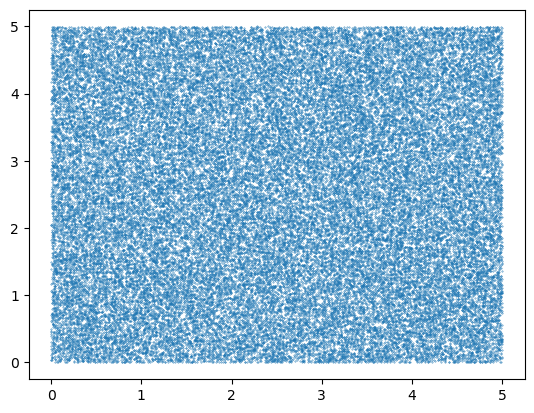

In [9]:
plt.scatter(randscut['RA'],randscut['DEC'],s=0.1)

In [37]:
print(rantable[0])
rantable['RA'] = rantable['RA']+1
print(rantable[0])

        RA               DEC        MASKBITS
------------------ ---------------- --------
119.12595062343351 27.6359023087219        0
        RA               DEC        MASKBITS
------------------ ---------------- --------
120.12595062343351 27.6359023087219        0


In [39]:
#loadholes
holetableselg = []
holetableslrg = []
for i in range(117):
    spelg = Table.read("datafiles/Holes_ELG_SV3_tile"+str(i)+"_holes.csv",format = "csv")
    splrg = Table.read("datafiles/Holes_LRG_SV3_tile"+str(i)+"_holes.csv",format = "csv")
    holetableselg.append(spelg)
    holetableslrg.append(splrg)
holetableelg = vstack(holetableselg)
holetablelrg = vstack(holetableslrg)
print(len(holetableelg),len(holetablelrg))

4646361 4697603


In [40]:
file_elgS = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_HIP_S_clustering.dat.fits'#'/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_HIPnotqso_S_clustering.dat.fits'
file_elgN = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_HIP_N_clustering.dat.fits'#'/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_HIPnotqso_N_clustering.dat.fits'
file_lrgS = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/LRG_main_S_clustering.dat.fits'
file_lrgN = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/LRG_main_N_clustering.dat.fits'
columns = ['RA','DEC','Z']
columnnames = columns[:3]
sp1 = Table(fitsio.read(file_elgN, columns=columns))
sp2 = Table(fitsio.read(file_elgS, columns=columns))
sp3 = Table(fitsio.read(file_lrgN, columns=columns))
sp4 = Table(fitsio.read(file_lrgS, columns=columns))
spE = vstack([sp1,sp2])
spL = vstack([sp3,sp4])

In [41]:
holetableelg['RA'],holetableelg['DEC'] = UnitSphereToRaDecPosRA(holetableelg['x'],holetableelg['y'],holetableelg['z'])

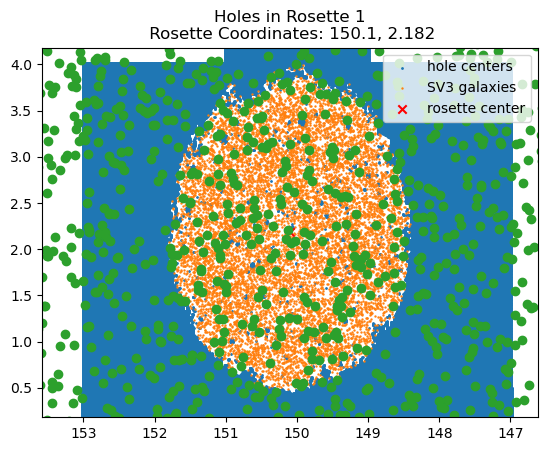

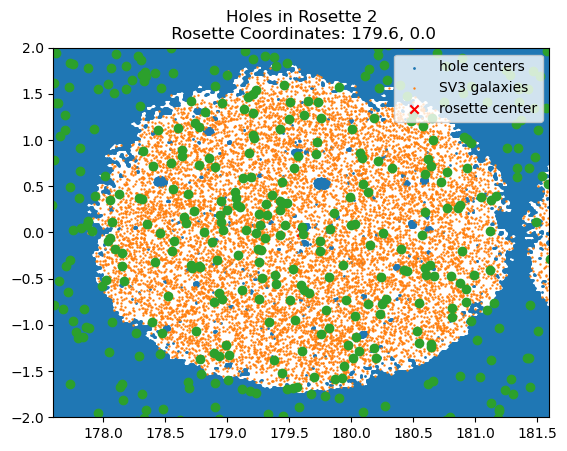

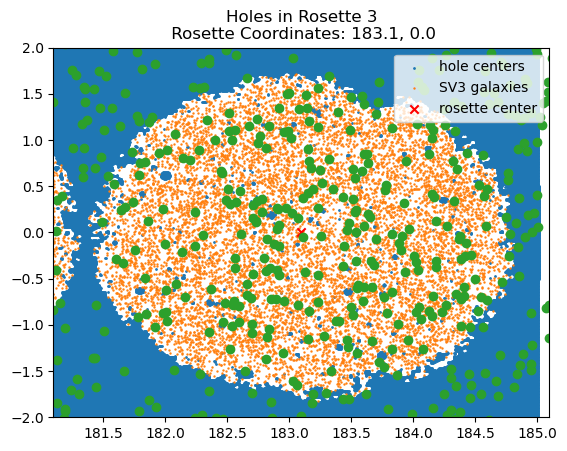

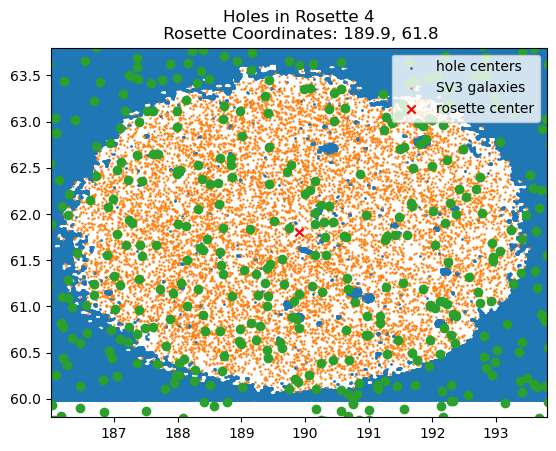

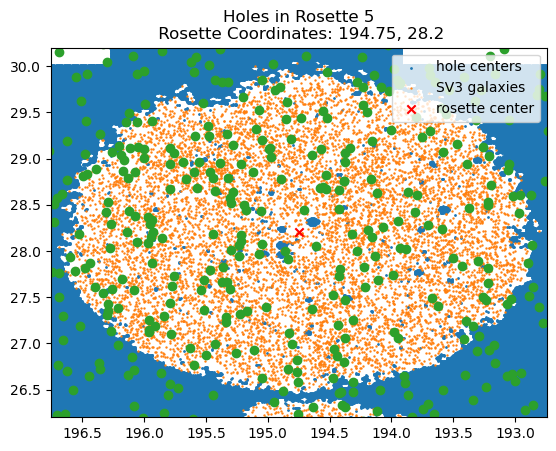

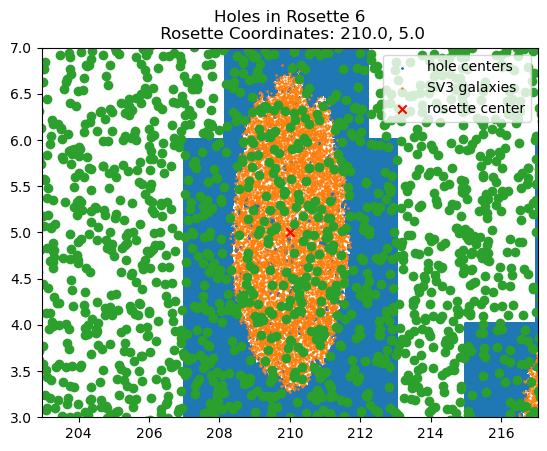

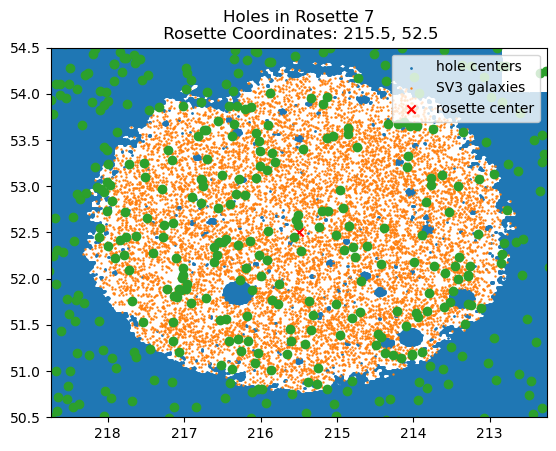

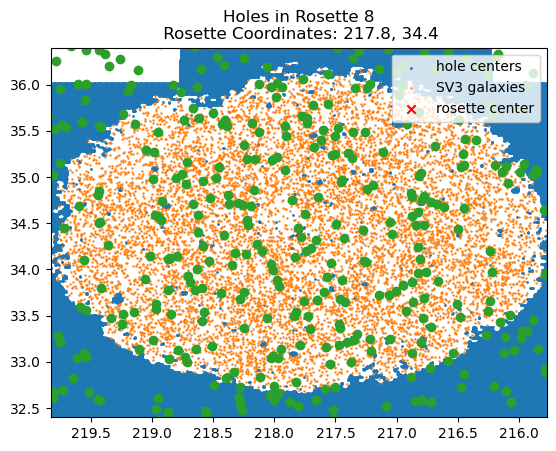

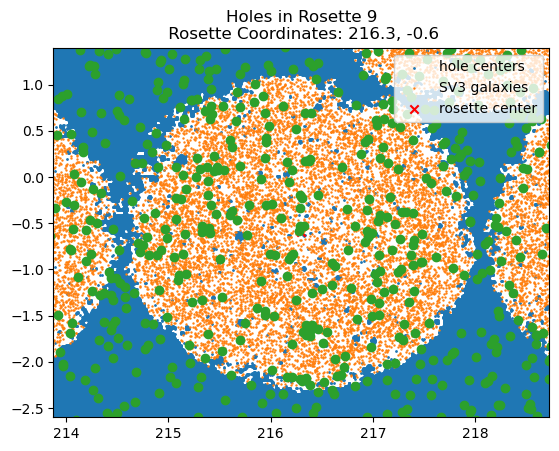

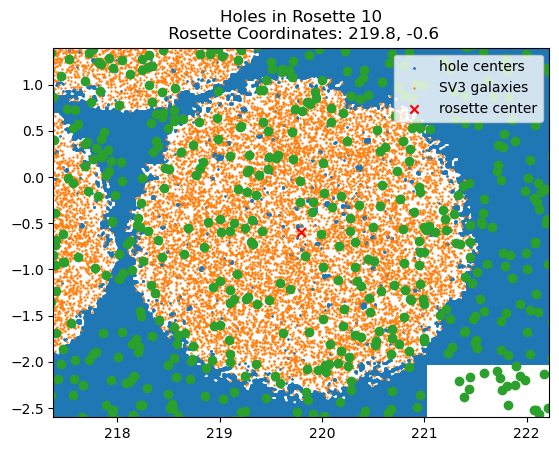

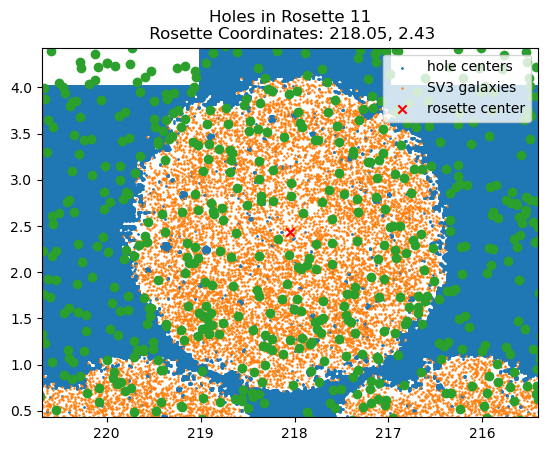

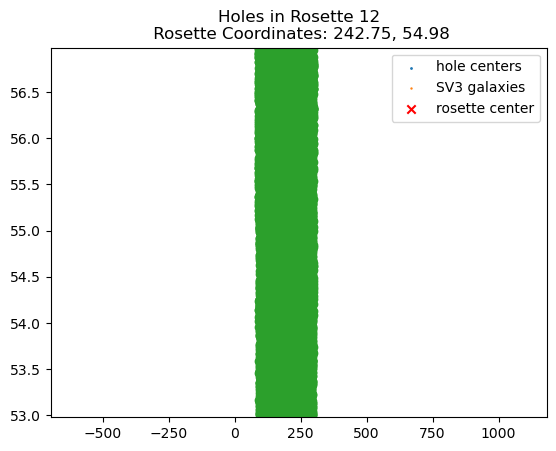

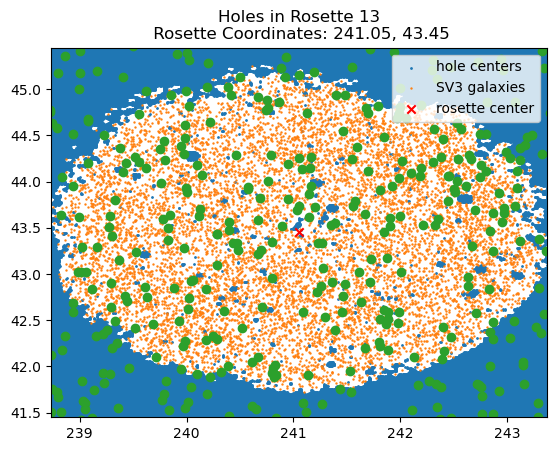

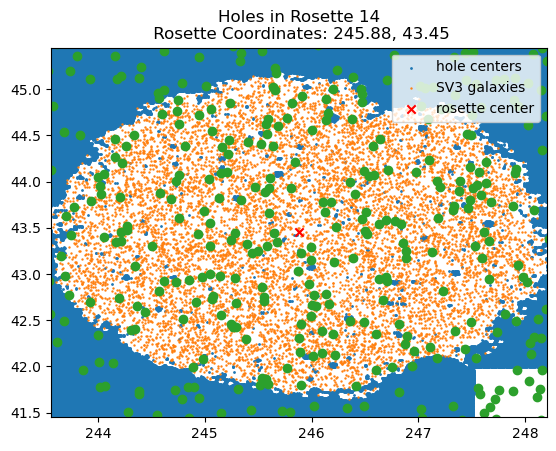

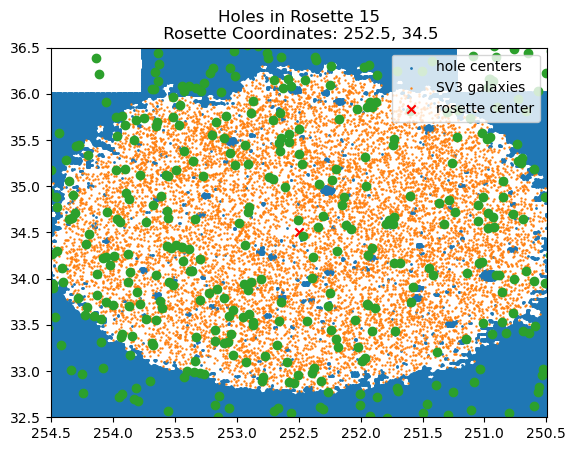

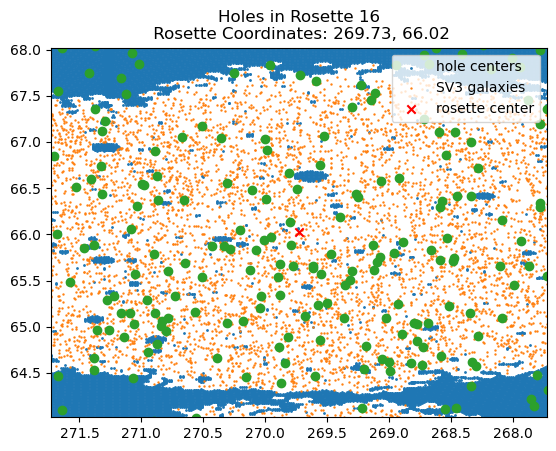

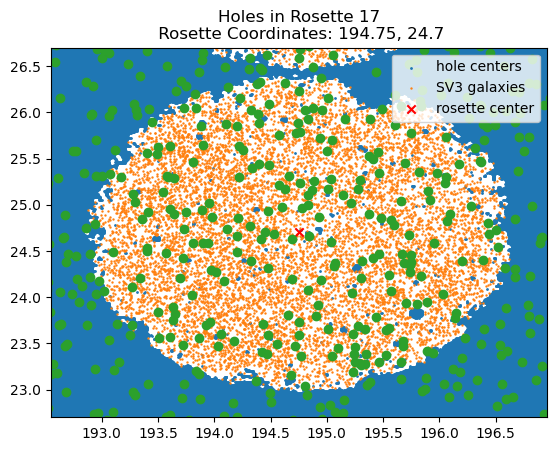

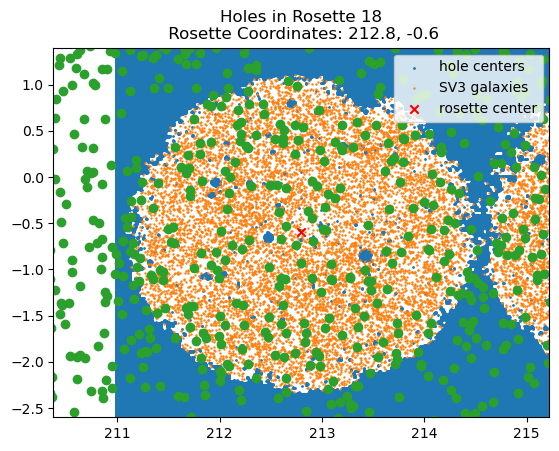

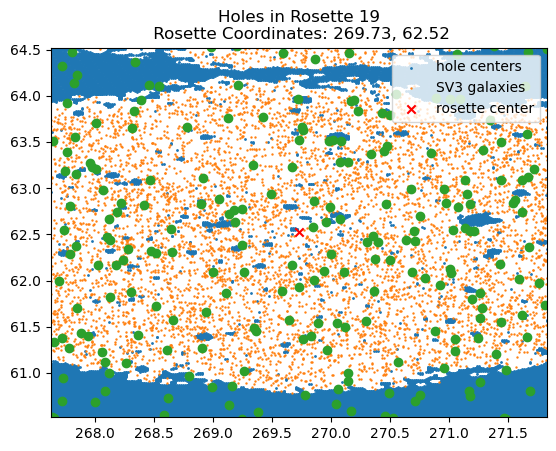

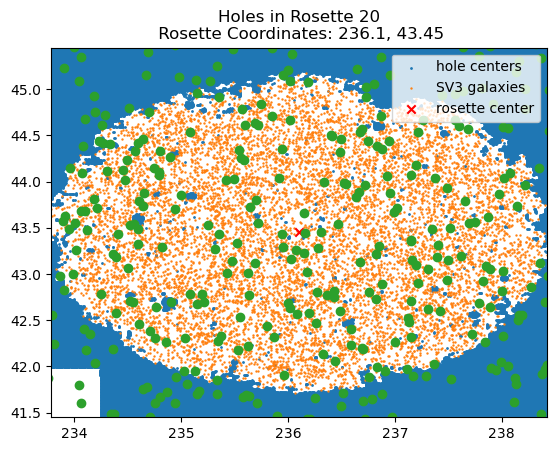

In [42]:
#plt.scatter(holetableelg['RA'],holetableelg['DEC'])
rosettes['RAmin'] = np.array(rosettes['RA']) - 1/np.cos(np.array(rosettes['DEC']))*2
rosettes['RAmax'] = np.array(rosettes['RA']) + 1/np.cos(np.array(rosettes['DEC']))*2
rosettes['DECmin'] = np.array(rosettes['DEC']) - 2
rosettes['DECmax'] = np.array(rosettes['DEC']) + 2

for i in range(20):
    plt.figure()
    plt.title("Holes in Rosette "+str(i+1)+"\n Rosette Coordinates: "+str(rosettes['RA'][i])+", "+str(rosettes['DEC'][i]))
    plt.scatter(holetableelg['RA'],holetableelg['DEC'],s=1,label = "hole centers")
    plt.xlim(rosettes['RAmin'][i],rosettes['RAmax'][i])
    plt.ylim(rosettes['DECmin'][i],rosettes['DECmax'][i])
    plt.scatter(spE['RA'],spE['DEC'],s=0.5,label = "SV3 galaxies")
    plt.scatter(rosettes['RA'][i],rosettes['DEC'][i],label = 'rosette center',marker='x',color='red')
    plt.legend(loc = 'upper right')
    plt.scatter(rantable['RA'][::100],rantable['DEC'][::100])

## check Abacus

In [25]:
#loadholes
holetableselg = []
holetableslrg = []
for i in range(240):
    spelg = Table.read("datafiles/forFAelg_tile"+str(i)+"_holes.csv",format = "csv")
    splrg = Table.read("datafiles/forFAlrg_tile"+str(i)+"_holes.csv",format = "csv")
    holetableselg.append(spelg)
    holetableslrg.append(splrg)
holetableelg = vstack(holetableselg)
holetablelrg = vstack(holetableslrg)
print(len(holetableelg),len(holetablelrg))

2218580 2349008


In [26]:
holetableelg['RA'],holetableelg['DEC'] = UnitSphereToRaDecPosRA(holetableelg['x'],holetableelg['y'],holetableelg['z'])

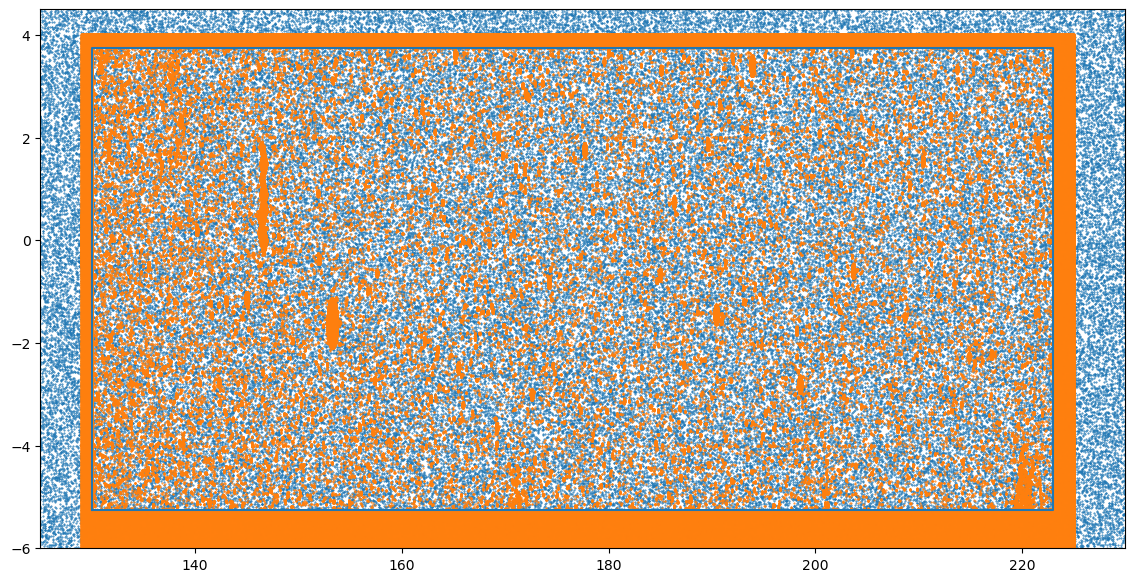

In [30]:
plt.figure(figsize=(14,7))
plt.scatter(rantable['RA'][::20],rantable['DEC'][::20],s=0.2)
plt.scatter(holetableelg['RA'],holetableelg['DEC'],s=0.2)
ralim = [130,223]
declim  = [-5.25,3.75]
plt.xlim(125,230)
plt.ylim(-6,4.5)
plt.plot([130,223,223,130,130],[-5.25,-5.25,3.75,3.75,-5.25])

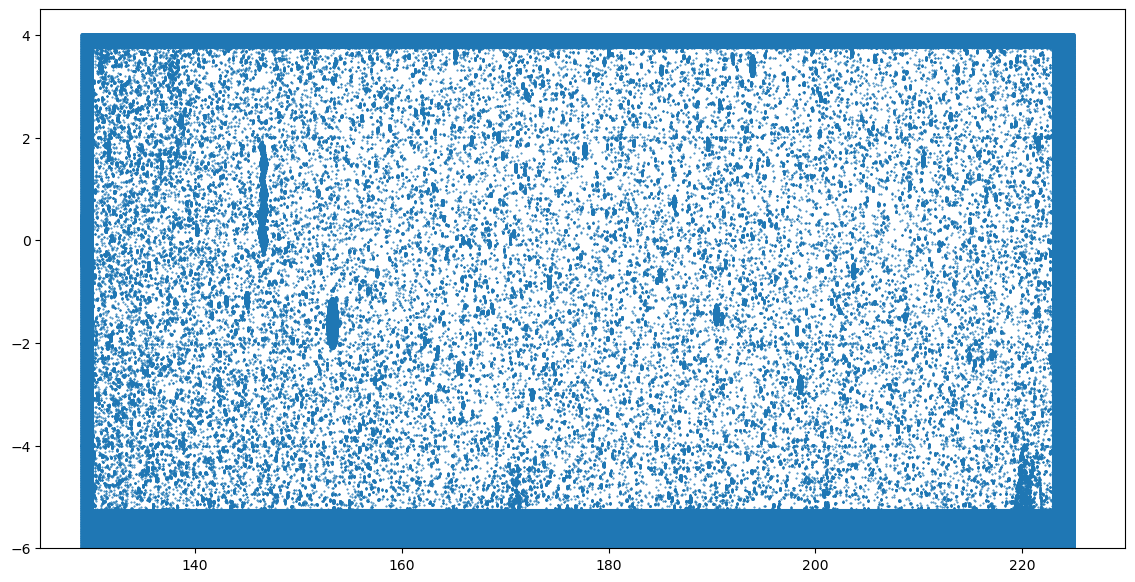

In [31]:
plt.figure(figsize=(14,7))
#plt.scatter(rantable['RA'][::20],rantable['DEC'][::20],s=0.2)
plt.scatter(holetableelg['RA'],holetableelg['DEC'],s=0.2)
ralim = [130,223]
declim  = [-5.25,3.75]
plt.xlim(125,230)
plt.ylim(-6,4.5)
plt.plot([130,223,223,130,130],[-5.25,-5.25,3.75,3.75,-5.25],color ='red')

In [34]:
randscut = rantable[(rantable['RA']>ralim[0])&(rantable['DEC'] > declim[0])&(rantable['RA'] < ralim[1])&(rantable['DEC'] < declim[1])]

(array([83068., 83975., 83399., 83396., 83489., 83703., 83495., 83070.,
        83356., 83289., 82751., 83537., 83977., 83815., 83961., 84008.,
        83768., 83714., 83163., 83634., 83162., 83657., 83738., 83991.,
        83841.]),
 array([-5.24999336, -4.88999393, -4.5299945 , -4.16999507, -3.80999564,
        -3.44999621, -3.08999678, -2.72999736, -2.36999793, -2.0099985 ,
        -1.64999907, -1.28999964, -0.93000021, -0.57000078, -0.21000135,
         0.14999808,  0.50999751,  0.86999694,  1.22999636,  1.58999579,
         1.94999522,  2.30999465,  2.66999408,  3.02999351,  3.38999294,
         3.74999237]),
 <BarContainer object of 25 artists>)

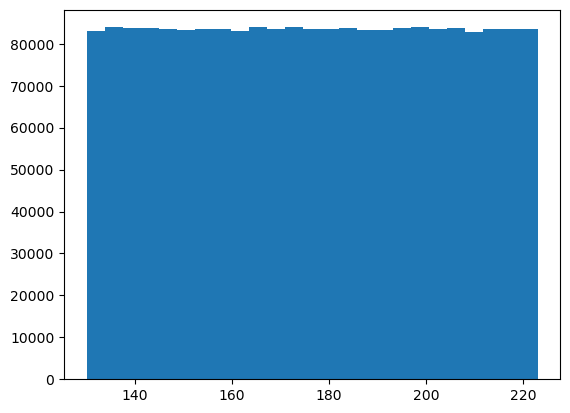

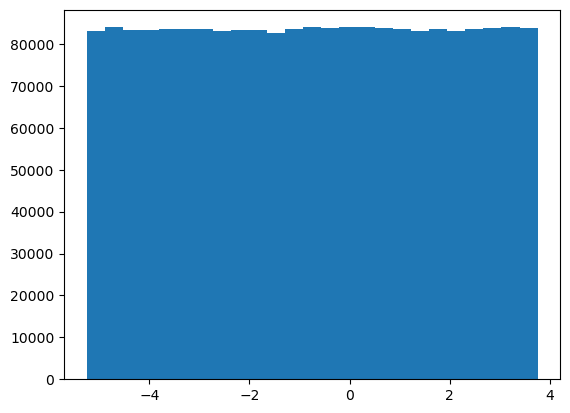

In [36]:
plt.hist(randscut['RA'],bins=25)
plt.figure()
plt.hist(randscut['DEC'],bins=25)